# Deep Hedging with Black-Scholes and Heston Baselines

**Author/Contributor:** Antareep Gogoi

This notebook compares classical delta hedging against neural-network hedging policies for a short at-the-money European call. The setup follows the deep-hedging framework of Bühler et al., where a neural network represents a hedge policy mapping the current market state to the next hedge action [Buehler2019].

The **hedging strategies** demonstrated in this notebook are the following:

1. Analytical **Black-Scholes delta** hedge for GBM / Black-Scholes [BlackScholes1973].
2. Semi-analytical **Heston delta** hedge for Heston stochastic volatility [Heston1993].
3. A **Simple** neural-network hedge.
4. A **Recurrent** neural-network hedge that sees the previous hedge position, following the idea that transaction-cost-aware hedging should depend on current holdings as well as current prices [Buehler2019].

**Market simulations** used for the purpose of this project are:

- GBM / Black-Scholes market, with and without transaction costs.
- Heston stochastic-volatility market, with and without transaction costs.

In [1]:
from pathlib import Path
import sys

# Set the root directory to the project root, which is assumed to be either the current working directory or its parent if a "src" folder exists.
HERE = Path.cwd()
if (HERE / "src").exists():
    ROOT = HERE
elif (HERE.parent / "src").exists():
    ROOT = HERE.parent
else:
    ROOT = HERE
sys.path.insert(0, str(ROOT))

import torch
# Limit the number of threads used by PyTorch to a maximum of 4 to avoid excessive CPU usage.
torch.set_num_threads(min(torch.get_num_threads(), 4))
import pandas as pd
import matplotlib.pyplot as plt

from src.deep_hedging_gbm_heston import (
    ExperimentConfig,
    SimplePolicy,
    RecurrentPolicy,
    HestonSimplePolicy,
    HestonRecurrentPolicy,
    initial_bs_price,
    initial_heston_price,
    simulate_gbm,
    simulate_heston,
    train_policy,
    pnl_cost_turnover_bs_delta,
    pnl_cost_turnover_heston_delta,
    pnl_cost_turnover_policy,
    comparison_table,
)
from src.deep_hedging_gbm_heston.plots import (
    plot_pnl_distributions,
    plot_realized_vol_comparison,
)

OUTPUT_DIR = ROOT / "outputs"
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)



## Experiment configuration

For a fast demo, keep `RUN_FULL_EXPERIMENT = False`.

For final project numbers, set it to `True`. The full setting uses more epochs and more test paths, so it will take longer on a laptop.


In [6]:
RUN_FULL_EXPERIMENT = True  # Set to False for a quick version for smoke testing.

if RUN_FULL_EXPERIMENT:
    BASE = ExperimentConfig(
        epochs=250,
        batch_size=4096,
        eval_paths=100_000,
        seed=123,
    )
else:
    # Quick version for reviewers or smoke testing.
    BASE = ExperimentConfig(
        epochs=10,
        batch_size=1024,
        eval_paths=5_000,
        seed=123,
    )

print(BASE)
print(f"Initial Black-Scholes call price: {initial_bs_price(BASE):.6f}")
print(f"Initial Heston call price:        {initial_heston_price(BASE):.6f}")


ExperimentConfig(S0=100.0, K=100.0, sigma=0.2, mu=0.0, r=0.0, T=0.0821917808219178, N=22, cost_gamma=0.0, hidden=15, batch_size=4096, epochs=250, lr=0.005, eval_paths=100000, seed=123, device='cpu', heston_kappa=3.0, heston_theta=0.04000000000000001, heston_xi=0.6, heston_rho=-0.7)
Initial Black-Scholes call price: 2.287148
Initial Heston call price:        2.222903


## Helper functions: train and evaluate one scenario

Each scenario chooses:

- a training market simulator,
- a test market,
- a transaction cost level,
- the correct classical baseline.

The table reports mean P&L, standard deviation, RMSE, VaR/CVaR loss, average cost, and turnover. The transaction-cost term follows the deep-hedging convention of penalizing trades through a non-negative trading-cost function; here we use the simple proportional cost \(c_t(a)=\gamma S_t |a|\) [Buehler2019].

For Heston scenarios, the neural-network policies are also given the current variance state. This is important because the true Heston delta depends on both \(S_t\) and \(v_t\) [Heston1993].


In [13]:
def run_gbm_scenario(cfg, test_sample, scenario_name):
    """Train GBM-state NN policies and compare them to BS delta hedging."""
    torch.manual_seed(cfg.seed)

    premium = initial_bs_price(cfg)
    simple = SimplePolicy(cfg)
    recurrent = RecurrentPolicy(cfg)

    print(f"\nTraining Simple policy for: {scenario_name}")
    simple_hist = train_policy(
        simple, cfg, simulate_gbm,
        name="Simple", initial_premium=premium, verbose=True,
    )

    print(f"\nTraining Recurrent policy for: {scenario_name}")
    recurrent_hist = train_policy(
        recurrent, cfg, simulate_gbm,
        name="Recurrent", initial_premium=premium, verbose=True,
    )

    S_test = test_sample

    with torch.no_grad():
        results = {
            "Black-Scholes delta": pnl_cost_turnover_bs_delta(S_test, cfg, premium),
            "Simple NN": pnl_cost_turnover_policy(simple, S_test, cfg, premium),
            "Recurrent NN": pnl_cost_turnover_policy(recurrent, S_test, cfg, premium),
        }

    table = comparison_table(results).round(5)
    table.to_csv(OUTPUT_DIR / "tables" / f"{scenario_name.replace(' ', '_').lower()}_metrics.csv")

    return {
        "table": table,
        "results": results,
        "simple_history": simple_hist,
        "recurrent_history": recurrent_hist,
        "premium": premium,
    }


def run_heston_scenario(cfg, test_sample, scenario_name):
    """Train Heston-state NN policies and compare them to the true Heston delta baseline."""
    torch.manual_seed(cfg.seed)

    # Use the Heston fair value as the common initial premium for every strategy
    # in the Heston market. This keeps the comparison focused on hedging.
    premium = initial_heston_price(cfg)
    simple = HestonSimplePolicy(cfg)
    recurrent = HestonRecurrentPolicy(cfg)

    print(f"\nTraining Heston-state Simple policy for: {scenario_name}")
    simple_hist = train_policy(
        simple, cfg, simulate_heston,
        name="Heston Simple", initial_premium=premium, verbose=True,
    )

    print(f"\nTraining Heston-state Recurrent policy for: {scenario_name}")
    recurrent_hist = train_policy(
        recurrent, cfg, simulate_heston,
        name="Heston Recurrent", initial_premium=premium, verbose=True,
    )

    S_test, v_test = test_sample

    with torch.no_grad():
        results = {
            "Black-Scholes delta": pnl_cost_turnover_bs_delta(S_test, cfg, premium),
            "Heston delta": pnl_cost_turnover_heston_delta(S_test, v_test, cfg, premium),
            "Heston-state Simple NN": pnl_cost_turnover_policy(simple, S_test, cfg, premium, extra_state=v_test),
            "Heston-state Recurrent NN": pnl_cost_turnover_policy(recurrent, S_test, cfg, premium, extra_state=v_test),
        }

    table = comparison_table(results).round(5)
    table.to_csv(OUTPUT_DIR / "tables" / f"{scenario_name.replace(' ', '_').lower()}_metrics.csv")

    return {
        "table": table,
        "results": results,
        "simple_history": simple_hist,
        "recurrent_history": recurrent_hist,
        "premium": premium,
    }


## 1. GBM market without transaction costs

This is the sanity check. Under GBM with no transaction costs, Black-Scholes delta hedging is the classical benchmark [BlackScholes1973]. The neural-network policies should approach similar hedging error behavior if the training setup is working.


In [8]:
cfg_gbm_no_cost = BASE.with_updates(cost_gamma=0.0)
S_gbm_no_cost_test = simulate_gbm(cfg_gbm_no_cost.eval_paths, cfg_gbm_no_cost)

gbm_no_cost = run_gbm_scenario(
    cfg_gbm_no_cost,
    S_gbm_no_cost_test,
    "GBM no cost",
)

display(gbm_no_cost["table"])



Training Simple policy for: GBM no cost
Simple             epoch    1/250, loss=3.065986
Simple             epoch   50/250, loss=2.777914
Simple             epoch  100/250, loss=1.729869
Simple             epoch  150/250, loss=0.684075
Simple             epoch  200/250, loss=0.305765
Simple             epoch  250/250, loss=0.229506

Training Recurrent policy for: GBM no cost
Recurrent          epoch    1/250, loss=3.081871
Recurrent          epoch   50/250, loss=2.767199
Recurrent          epoch  100/250, loss=1.309775
Recurrent          epoch  150/250, loss=0.589023
Recurrent          epoch  200/250, loss=0.384674
Recurrent          epoch  250/250, loss=0.287189


,Mean P&L,Std P&L,RMSE,5% VaR Loss,5% CVaR Loss,Avg Cost,Avg Turnover
Strategy,,,,,,,
Black-Scholes delta,-0.00262,0.41603,0.41603,0.69957,0.97939,0.0,2.45322
Simple NN,-0.00232,0.47483,0.47483,0.78154,1.03561,0.0,2.50443
Recurrent NN,-0.00091,0.53786,0.53785,0.88572,1.21451,0.0,2.11207


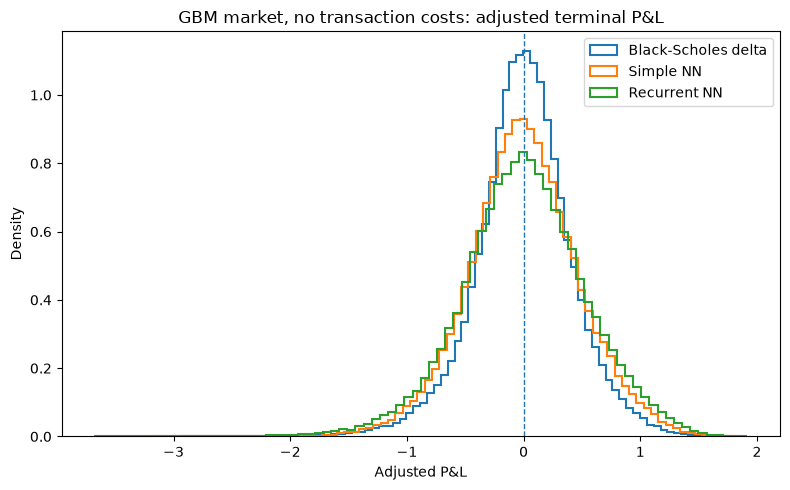

In [9]:

plot_pnl_distributions(
    {k: v[0] for k, v in gbm_no_cost["results"].items()},
    adjust_mean=True,
    title="GBM market, no transaction costs: adjusted terminal P&L",
    save_path=OUTPUT_DIR / "figures" / "gbm_no_cost_adjusted_pnl.png",
)
plt.show()


## 2. GBM market with transaction costs

Now we add proportional transaction costs. The BS delta hedge keeps rebalancing, so it can pay a lot of cost. The Simple NN does not know its previous position. The Recurrent NN does, so it can learn to trade less aggressively. This mirrors the motivation in deep hedging: with market frictions, the optimal action can depend on both current market state and current hedge position [Buehler2019].


In [10]:
cfg_gbm_cost = BASE.with_updates(cost_gamma=0.005)
S_gbm_cost_test = simulate_gbm(cfg_gbm_cost.eval_paths, cfg_gbm_cost)

gbm_cost = run_gbm_scenario(
    cfg_gbm_cost,
    S_gbm_cost_test,
    "GBM with cost",
)

display(gbm_cost["table"])



Training Simple policy for: GBM with cost
Simple             epoch    1/250, loss=4.260803
Simple             epoch   50/250, loss=3.279242
Simple             epoch  100/250, loss=3.086663
Simple             epoch  150/250, loss=3.018283
Simple             epoch  200/250, loss=2.478183
Simple             epoch  250/250, loss=1.741913

Training Recurrent policy for: GBM with cost
Recurrent          epoch    1/250, loss=4.485115
Recurrent          epoch   50/250, loss=3.276709
Recurrent          epoch  100/250, loss=3.088032
Recurrent          epoch  150/250, loss=2.991756
Recurrent          epoch  200/250, loss=2.326745
Recurrent          epoch  250/250, loss=1.576130


,Mean P&L,Std P&L,RMSE,5% VaR Loss,5% CVaR Loss,Avg Cost,Avg Turnover
Strategy,,,,,,,
Black-Scholes delta,-1.23819,0.58176,1.36805,2.28784,2.66439,1.23666,2.45239
Simple NN,-0.78500,1.06845,1.32582,2.78544,3.47678,0.78551,1.55873
Recurrent NN,-0.76755,1.00139,1.26171,2.65216,3.34929,0.76674,1.51886


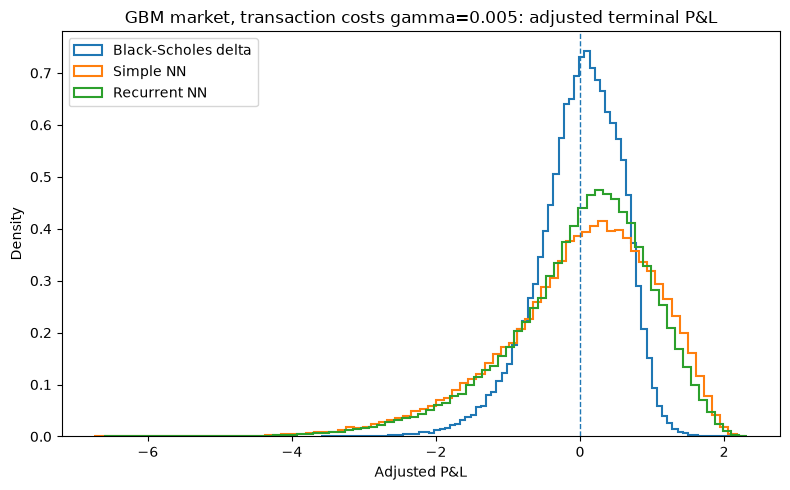

In [11]:

plot_pnl_distributions(
    {k: v[0] for k, v in gbm_cost["results"].items()},
    adjust_mean=True,
    title=f"GBM market, transaction costs gamma={cfg_gbm_cost.cost_gamma}: adjusted terminal P&L",
    save_path=OUTPUT_DIR / "figures" / "gbm_with_cost_adjusted_pnl.png",
)
plt.show()


## 3. Heston market without transaction costs

Here the test market has stochastic volatility. The correct classical benchmark is the Heston delta hedge, computed from the semi-analytical Heston model price [Heston1993]. We also include Black-Scholes delta as a misspecified comparison.

### Important notes:
The Heston section uses a true Heston model baseline. The Heston price and spot delta are computed from the Heston characteristic function [Heston1993]. For Heston market, Black-Scholes delta with an instantaneous volatility plug-in is NOT the correct classical benchmark. The model-consistent Heston stock hedge would be:

$$
\Delta^{\mathrm{Heston}}(t,S_t,v_t)=\frac{\partial V^{\mathrm{Heston}}}{\partial S}(t,S_t,v_t),
$$

where the current variance \(v_t\) is part of the state. In this notebook, the Heston delta is computed with the semi-analytical Heston characteristic-function formula [Heston1993]. We still report both Black-Scholes delta in the Heston market as a comparison along with **Heston delta**, which is the true model-consistent Heston stock-delta baseline.

The deep-hedging framework stresses that the market state should contain all relevant observable information; otherwise the learned policy is solving the wrong state-space problem [Buehler2019, BuehlerHorvath2022].


In [14]:
cfg_heston_no_cost = BASE.with_updates(cost_gamma=0.0)
S_heston_no_cost_test, v_heston_no_cost_test = simulate_heston(
    cfg_heston_no_cost.eval_paths,
    cfg_heston_no_cost,
)

heston_no_cost = run_heston_scenario(
    cfg_heston_no_cost,
    (S_heston_no_cost_test, v_heston_no_cost_test),
    "Heston no cost",
)

display(heston_no_cost["table"])



Training Heston-state Simple policy for: Heston no cost
Heston Simple      epoch    1/250, loss=3.081373
Heston Simple      epoch   50/250, loss=2.207248
Heston Simple      epoch  100/250, loss=1.526813
Heston Simple      epoch  150/250, loss=1.160680
Heston Simple      epoch  200/250, loss=0.824320
Heston Simple      epoch  250/250, loss=0.564433

Training Heston-state Recurrent policy for: Heston no cost
Heston Recurrent   epoch    1/250, loss=2.889239
Heston Recurrent   epoch   50/250, loss=2.026713
Heston Recurrent   epoch  100/250, loss=1.414653
Heston Recurrent   epoch  150/250, loss=0.890517
Heston Recurrent   epoch  200/250, loss=0.559399
Heston Recurrent   epoch  250/250, loss=0.509760


,Mean P&L,Std P&L,RMSE,5% VaR Loss,5% CVaR Loss,Avg Cost,Avg Turnover
Strategy,,,,,,,
Black-Scholes delta,-0.00875,0.60089,0.60095,1.02748,1.51927,0.0,2.44538
Heston delta,-0.00923,0.66938,0.66944,1.18546,1.54895,0.0,2.54913
Heston-state Simple NN,-0.01064,0.75328,0.75335,1.20315,1.66101,0.0,2.35901
Heston-state Recurrent NN,-0.00993,0.70477,0.70484,1.17785,1.70187,0.0,2.09040


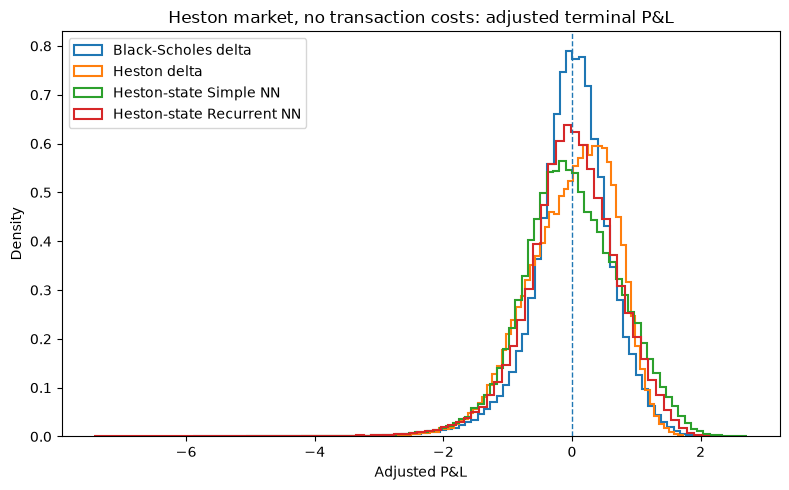

In [15]:

plot_pnl_distributions(
    {k: v[0] for k, v in heston_no_cost["results"].items()},
    adjust_mean=True,
    title="Heston market, no transaction costs: adjusted terminal P&L",
    save_path=OUTPUT_DIR / "figures" / "heston_no_cost_adjusted_pnl.png",
)
plt.show()


## 4. Heston market with transaction costs

This is the most realistic toy experiment in this contribution: volatility is stochastic and trading is costly. The Heston delta is model-consistent for the frictionless Heston model [Heston1993], but it can still trade too aggressively once transaction costs are added. The recurrent Heston-state NN can learn to balance hedge improvement against trading cost because it observes both current variance and previous hedge position, consistent with the deep-hedging policy-search setup [Buehler2019].


In [16]:
cfg_heston_cost = BASE.with_updates(cost_gamma=0.005)
S_heston_cost_test, v_heston_cost_test = simulate_heston(
    cfg_heston_cost.eval_paths,
    cfg_heston_cost,
)

heston_cost = run_heston_scenario(
    cfg_heston_cost,
    (S_heston_cost_test, v_heston_cost_test),
    "Heston with cost",
)

display(heston_cost["table"])



Training Heston-state Simple policy for: Heston with cost
Heston Simple      epoch    1/250, loss=4.171108
Heston Simple      epoch   50/250, loss=2.893090
Heston Simple      epoch  100/250, loss=2.592701
Heston Simple      epoch  150/250, loss=2.241746
Heston Simple      epoch  200/250, loss=1.992209
Heston Simple      epoch  250/250, loss=1.809722

Training Heston-state Recurrent policy for: Heston with cost
Heston Recurrent   epoch    1/250, loss=3.667123
Heston Recurrent   epoch   50/250, loss=2.888094
Heston Recurrent   epoch  100/250, loss=2.480433
Heston Recurrent   epoch  150/250, loss=1.988870
Heston Recurrent   epoch  200/250, loss=1.639071
Heston Recurrent   epoch  250/250, loss=1.406201


,Mean P&L,Std P&L,RMSE,5% VaR Loss,5% CVaR Loss,Avg Cost,Avg Turnover
Strategy,,,,,,,
Black-Scholes delta,-1.24153,0.73791,1.44427,2.62766,3.24047,1.23279,2.44538
Heston delta,-1.29312,0.70710,1.47382,2.57757,3.06018,1.28389,2.54913
Heston-state Simple NN,-0.77204,1.10602,1.34882,2.70870,3.44867,0.75897,1.51206
Heston-state Recurrent NN,-0.76221,0.90945,1.18662,2.36150,2.96418,0.74944,1.48870


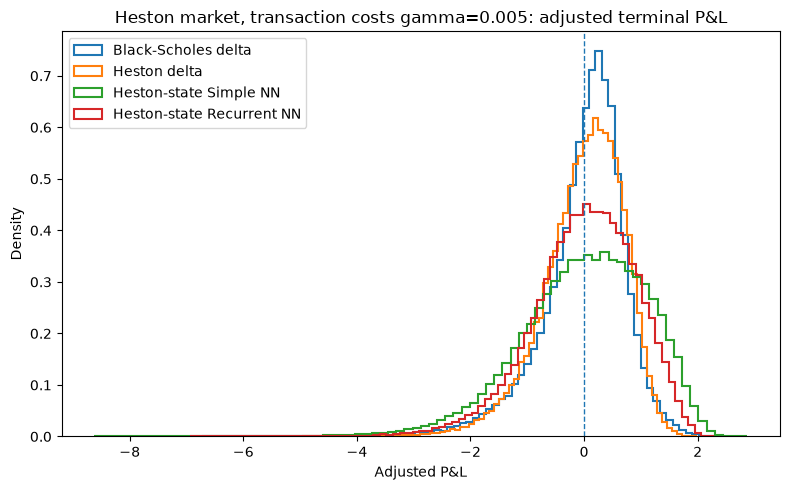

In [17]:

plot_pnl_distributions(
    {k: v[0] for k, v in heston_cost["results"].items()},
    adjust_mean=True,
    title=f"Heston market, transaction costs gamma={cfg_heston_cost.cost_gamma}: adjusted terminal P&L",
    save_path=OUTPUT_DIR / "figures" / "heston_with_cost_adjusted_pnl.png",
)
plt.show()


## GBM versus Heston realized volatility

This plot is a useful visual sanity check for the Heston simulator. GBM has a much tighter realized-volatility distribution around the fixed volatility, while Heston produces a wider distribution because variance itself is random [Heston1993].


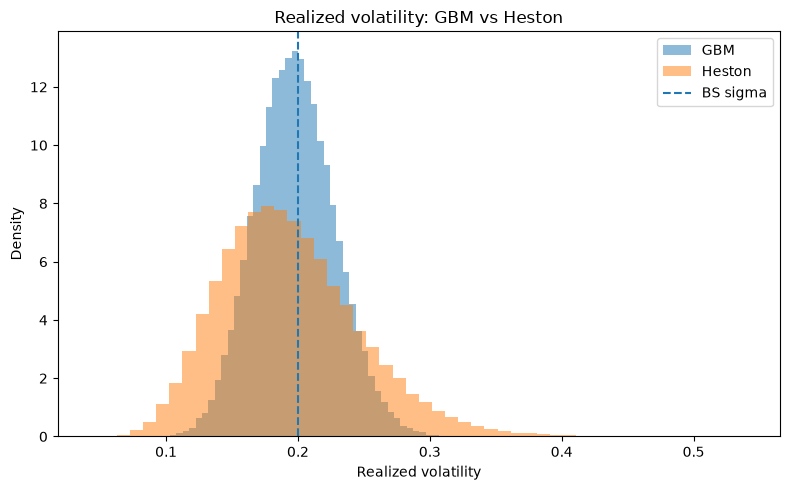

In [18]:

S_gbm_vol = simulate_gbm(BASE.eval_paths, BASE)
S_heston_vol, _ = simulate_heston(BASE.eval_paths, BASE)

plot_realized_vol_comparison(
    S_gbm_vol,
    S_heston_vol,
    BASE,
    save_path=OUTPUT_DIR / "figures" / "realized_vol_gbm_vs_heston.png",
)
plt.show()


## Summary of expected findings

- **GBM, no cost:** Black-Scholes delta is the strongest classical benchmark. NN policies performs poorly in comparision. However, this step works as a good sanity check.
- **GBM, with cost:** Recurrent NN becomes more useful compared to simple NN as it observes the previous hedge and tried to avoid unnecessary rebalancing. It has 
- **Heston, no cost:** Heston delta is the model-consistent classical which is used as our baseline and is being compared our deep-hedging models which perform relatively poorly without transaction costs.
- **Heston, with cost:** Heston delta is still a frictionless-model hedge, so it can trade too much when costs are present. A recurrent Heston-state NN may reduce cost-adjusted tail losses by trading less aggressively [Buehler2019].

The final project discussion should compare both raw P&L metrics and adjusted P&L distributions. The adjusted plot subtracts each strategy's own mean, so it focuses on the shape, dispersion, and tail risk of the hedging error rather than the initial premium convention.

## References

[Buehler2019] Hans Bühler, Lukas Gonon, Josef Teichmann, and Ben Wood. *Deep Hedging*. Quantitative Finance, 19(8), 1271–1291, 2019. arXiv:1802.03042.

[BuehlerHorvath2022] Hans Bühler and Blanka Horvath. *Learning to Trade II: Deep Hedging*. TU Munich lecture notes, 2022.

[BlackScholes1973] Fischer Black and Myron Scholes. *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3), 637–654, 1973.

[Heston1993] Steven L. Heston. *A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options*. The Review of Financial Studies, 6(2), 327–343, 1993.


Loading cached P&L arrays from /Users/antareepgogoi/Quant Finance/antareep_gbm_heston_patch 3/outputs/cache/heston_gamma_sweep_pnl.pkl


Mean P&L  Std P&L  Median P&L  CVaR50%(G)  \
cost_gamma Strategy                                                             
0.00       Analytical Heston delta  -0.00213  0.67087     0.07810    -0.54040   
           Recurrent NN deep hedge  -0.00287  0.72016     0.01037    -0.55868   
           Simple NN deep hedge     -0.00345  0.76632    -0.01312    -0.60601   
0.01       Analytical Heston delta  -2.57176  0.87616    -2.43212    -3.24696   
           Recurrent NN deep hedge  -0.90347  1.53012    -0.60251    -2.09909   
           Simple NN deep hedge     -0.89332  1.53859    -0.60480    -2.10231   
0.05       Analytical Heston delta -12.85026  3.28549   -12.68508   -15.49371   
           Recurrent NN deep hedge  -2.91826  1.94285    -2.35558    -4.38952   
           Simple NN deep hedge     -1.88269  2.24920    -1.00688    -3.53857   

                                    Score=-CVaR50%(G)  
cost_gamma Strategy                                    
0.00       Analytical Heston delta            0.54040  
           Recurrent NN deep hedge            0.55868  
           Simple NN deep hedge               0.60601  
0.01       Analytical Heston delta            3.24696  
           Recurrent NN deep hedge            2.09909  
           Simple NN deep hedge               2.10231  
0.05       Analytical Heston delta           15.49371  
           Recurrent NN deep hedge            4.38952  
           Simple NN deep hedge               3.53857

KeyError: 0.001

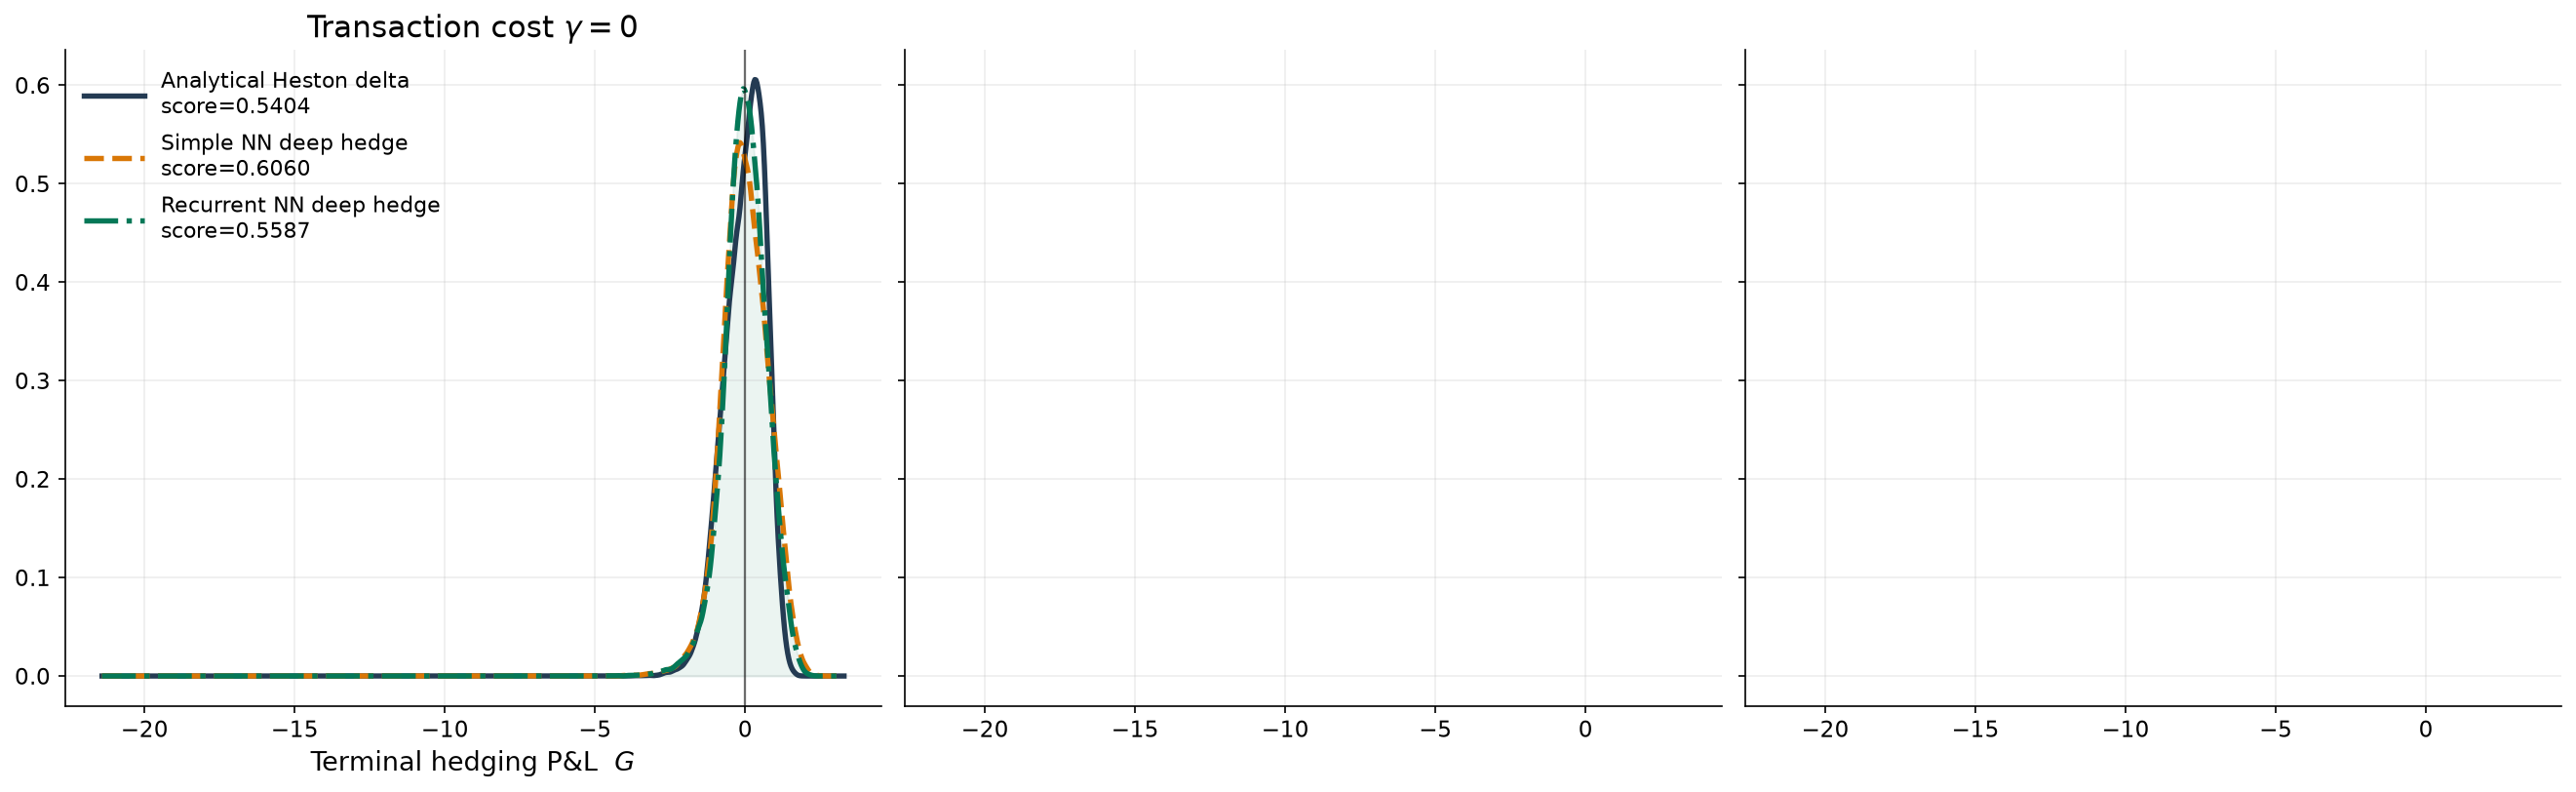

In [27]:
from pathlib import Path
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Make imports robust whether this notebook is run from repo root or notebooks/
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.deep_hedging_gbm_heston import (
    ExperimentConfig,
    HestonSimplePolicy,
    HestonRecurrentPolicy,
    simulate_heston,
    train_policy,
    initial_heston_price,
    pnl_cost_turnover_heston_delta,
    pnl_cost_turnover_policy,
)

# -------------------------
# User-facing controls
# -------------------------
COST_GAMMAS = [0.00, 0.001, 0.005]

# For final presentation, use something like 250 epochs and 100_000 eval paths.
# For a quick test, lower these to EPOCHS=20 and EVAL_PATHS=10_000.
EPOCHS = 250
EVAL_PATHS = 100_000
BATCH_SIZE = 4096
HIDDEN = 15
LR = 5e-3
SEED = 2026

# Heston delta quadrature. 64 is good for final plots; 32 is faster.
HESTON_DELTA_N_QUAD = 64

REUSE_CACHE = True
OUT_DIR = ROOT / "outputs" / "figures"
CACHE_DIR = ROOT / "outputs" / "cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / "heston_gamma_sweep_pnl.pkl"
FIG_PNG = OUT_DIR / "heston_gamma_sweep_density.png"
FIG_PDF = OUT_DIR / "heston_gamma_sweep_density.pdf"


# -------------------------
# Scoring utilities
# -------------------------
def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def cvar_left_tail(pnl, alpha=0.50):
    """
    CVaR_alpha(G) as the average of the worst alpha fraction of terminal P&L values.
    For alpha=0.50 this is the average P&L below the median.
    """
    g = to_numpy(pnl).astype(float)
    cutoff = np.quantile(g, alpha)
    return float(g[g <= cutoff].mean())


def score_neg_cvar50(pnl):
    """
    Project score:
        Score = -CVaR_50%(G)

    Lower score means better.
    """
    return -cvar_left_tail(pnl, alpha=0.50)


def summarize_pnl(pnl):
    g = to_numpy(pnl).astype(float)
    return {
        "Mean P&L": g.mean(),
        "Std P&L": g.std(ddof=1),
        "Median P&L": np.median(g),
        "CVaR50%(G)": cvar_left_tail(g, alpha=0.50),
        "Score=-CVaR50%(G)": score_neg_cvar50(g),
    }


# -------------------------
# Run or load experiment
# -------------------------
def run_one_gamma(cost_gamma, S_test, v_test):
    cfg = ExperimentConfig(
        cost_gamma=cost_gamma,
        epochs=EPOCHS,
        eval_paths=EVAL_PATHS,
        batch_size=BATCH_SIZE,
        hidden=HIDDEN,
        lr=LR,
        seed=SEED,
    )

    premium = initial_heston_price(cfg)

    simple = HestonSimplePolicy(cfg).to(cfg.device)
    recurrent = HestonRecurrentPolicy(cfg).to(cfg.device)

    print(f"\n=== Training Heston Simple NN | cost_gamma={cost_gamma} ===")
    train_policy(
        simple,
        cfg,
        simulate_heston,
        name=f"Heston Simple γ={cost_gamma}",
        initial_premium=premium,
        verbose=True,
    )

    print(f"\n=== Training Heston Recurrent NN | cost_gamma={cost_gamma} ===")
    train_policy(
        recurrent,
        cfg,
        simulate_heston,
        name=f"Heston Recurrent γ={cost_gamma}",
        initial_premium=premium,
        verbose=True,
    )

    with torch.no_grad():
        heston_delta_pnl, heston_delta_cost, heston_delta_turnover = pnl_cost_turnover_heston_delta(
            S_test,
            v_test,
            cfg,
            premium,
            n_quad=HESTON_DELTA_N_QUAD,
        )

        simple_pnl, simple_cost, simple_turnover = pnl_cost_turnover_policy(
            simple,
            S_test,
            cfg,
            premium,
            extra_state=v_test,
        )

        recurrent_pnl, recurrent_cost, recurrent_turnover = pnl_cost_turnover_policy(
            recurrent,
            S_test,
            cfg,
            premium,
            extra_state=v_test,
        )

    return {
        "Analytical Heston delta": to_numpy(heston_delta_pnl),
        "Simple NN deep hedge": to_numpy(simple_pnl),
        "Recurrent NN deep hedge": to_numpy(recurrent_pnl),
    }


if REUSE_CACHE and CACHE_FILE.exists():
    print(f"Loading cached P&L arrays from {CACHE_FILE}")
    with open(CACHE_FILE, "rb") as f:
        all_results = pickle.load(f)

else:
    base_cfg = ExperimentConfig(
        cost_gamma=0.0,
        epochs=EPOCHS,
        eval_paths=EVAL_PATHS,
        batch_size=BATCH_SIZE,
        hidden=HIDDEN,
        lr=LR,
        seed=SEED,
    )

    torch.manual_seed(SEED)
    S_test, v_test = simulate_heston(EVAL_PATHS, base_cfg)

    all_results = {}
    for gamma in COST_GAMMAS:
        all_results[gamma] = run_one_gamma(gamma, S_test, v_test)

    with open(CACHE_FILE, "wb") as f:
        pickle.dump(all_results, f)
    print(f"\nSaved cached P&L arrays to {CACHE_FILE}")


# -------------------------
# Score table
# -------------------------
rows = []
for gamma, strategy_dict in all_results.items():
    for strategy, pnl in strategy_dict.items():
        row = summarize_pnl(pnl)
        row["cost_gamma"] = gamma
        row["Strategy"] = strategy
        rows.append(row)

score_table = (
    pd.DataFrame(rows)
    .set_index(["cost_gamma", "Strategy"])
    .sort_index()
)

display(score_table.round(5))


# -------------------------
# Aesthetic density plot
# -------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.8,
})

colors = {
    "Analytical Heston delta": "#243B53",
    "Simple NN deep hedge": "#D97706",
    "Recurrent NN deep hedge": "#047857",
}

linestyles = {
    "Analytical Heston delta": "-",
    "Simple NN deep hedge": "--",
    "Recurrent NN deep hedge": "-.",
}

# Robust common x-limits across all panels, avoiding extreme KDE stretching.
pooled = np.concatenate([
    np.asarray(pnl, dtype=float)
    for gamma_results in all_results.values()
    for pnl in gamma_results.values()
])
x_low, x_high = np.quantile(pooled, [0.0025, 0.9975])
pad = 0.08 * (x_high - x_low)
x_grid = np.linspace(x_low - pad, x_high + pad, 700)

fig, axes = plt.subplots(
    1,
    len(COST_GAMMAS),
    figsize=(17.5, 5.3),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

if len(COST_GAMMAS) == 1:
    axes = [axes]

for ax, gamma in zip(axes, COST_GAMMAS):
    strategy_dict = all_results[gamma]

    for strategy, pnl in strategy_dict.items():
        pnl = np.asarray(pnl, dtype=float)

        kde = gaussian_kde(pnl)
        density = kde(x_grid)

        score = score_neg_cvar50(pnl)
        label = f"{strategy}\nscore={score:.4f}"

        ax.plot(
            x_grid,
            density,
            color=colors[strategy],
            linestyle=linestyles[strategy],
            linewidth=2.6,
            label=label,
        )

        # Light fill only for the recurrent model, to highlight the proposed method.
        if strategy == "Recurrent NN deep hedge":
            ax.fill_between(
                x_grid,
                0,
                density,
                color=colors[strategy],
                alpha=0.08,
            )

    ax.axvline(0.0, color="black", linewidth=1.1, alpha=0.55)
    ax.set_title(rf"Transaction cost $\gamma={gamma:g}$")
    ax.set_xlabel("Terminal hedging P&L  $G$")
    ax.legend(frameon=False, loc="upper left", handlelength=2.8)

axes[0].set_ylabel("Density")

fig.suptitle(
    "Heston test market: analytical delta vs deep hedging policies",
    fontsize=18,
    fontweight="bold",
    y=1.04,
)

fig.text(
    0.5,
    -0.035,
    r"Score $= -\mathrm{CVaR}_{50\%}(G)$, where $\mathrm{CVaR}_{50\%}(G)$ is the mean of the worst 50% of terminal P&L outcomes. Lower score is better.",
    ha="center",
    fontsize=11.5,
)

plt.savefig(FIG_PNG, bbox_inches="tight", facecolor="white")
plt.savefig(FIG_PDF, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure:\n  {FIG_PNG}\n  {FIG_PDF}")

In [24]:
# ============================================================
# Stable Heston NN training:
# 1. Pretrain NN to imitate analytical Heston stock delta.
# 2. Fine-tune directly on Score = -CVaR_50%(G).
# 3. Keep best model by validation score.
#
# This replaces the sketchy from-scratch MSE training.
# ============================================================

from copy import deepcopy
from pathlib import Path
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.deep_hedging_gbm_heston import (
    ExperimentConfig,
    HestonSimplePolicy,
    HestonRecurrentPolicy,
    simulate_heston,
    initial_heston_price,
    pnl_cost_turnover_heston_delta,
    pnl_cost_turnover_policy,
)

from src.deep_hedging_gbm_heston.heston import heston_delta_torch

# -------------------------
# Controls
# -------------------------
COST_GAMMAS = [0.00, 0.01, 0.05]

SEED = 2026
HIDDEN = 15
BATCH_SIZE = 4096
EVAL_PATHS = 100_000

# Teacher pretraining: make NN learn the model-consistent Heston delta surface.
PRETRAIN_PATHS = 12_000
PRETRAIN_EPOCHS = 120
PRETRAIN_BATCH_PATHS = 1024
PRETRAIN_LR = 1e-3
PRETRAIN_N_QUAD = 24   # lower than final evaluation, but enough for teacher pretraining

# Fine-tuning: optimize our actual project score.
FINETUNE_EPOCHS_PER_STAGE = 150
FINETUNE_LR = 3e-4
VAL_PATHS = 20_000
VAL_EVERY = 25

# Final analytical Heston delta evaluation.
HESTON_DELTA_N_QUAD = 64

OUT_DIR = ROOT / "outputs" / "figures"
CACHE_DIR = ROOT / "outputs" / "cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / "heston_gamma_sweep_pnl_stable.pkl"

# Important: set this False after changing the training protocol.
REUSE_CACHE = False


# -------------------------
# Score utilities
# -------------------------
def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def cvar_left_tail_np(pnl, alpha=0.50):
    """
    CVaR_alpha(G) = average of the worst alpha fraction of terminal P&L values.
    For alpha=0.50 this is the average below the median.
    """
    g = to_numpy(pnl).astype(float)
    cutoff = np.quantile(g, alpha)
    return float(g[g <= cutoff].mean())


def score_neg_cvar50_np(pnl):
    """
    Project score:
        Score = -CVaR_50%(G)

    Lower score means better.
    """
    return -cvar_left_tail_np(pnl, alpha=0.50)


def score_loss_torch(pnl):
    """
    Differentiable-ish minibatch version of Score = -CVaR_50%(G).

    We detach the median cutoff so the objective is stable:
    optimize the mean of the current bad half of the batch.
    """
    q = torch.quantile(pnl.detach(), 0.50)
    tail = pnl[pnl <= q]
    return -tail.mean()


def summarize_pnl(pnl):
    g = to_numpy(pnl).astype(float)
    return {
        "Mean P&L": g.mean(),
        "Std P&L": g.std(ddof=1),
        "Median P&L": np.median(g),
        "CVaR50%(G)": cvar_left_tail_np(g, alpha=0.50),
        "Score=-CVaR50%(G)": score_neg_cvar50_np(g),
    }


# -------------------------
# Heston teacher target
# -------------------------
@torch.no_grad()
def heston_delta_targets(S, v, cfg, *, n_quad=24):
    """
    Compute analytical Heston delta targets for all hedge dates.

    Output shape:
        [n_paths, N]
    """
    targets = []
    for t in range(cfg.N):
        tau = cfg.T * (cfg.N - t) / cfg.N
        delta_t = heston_delta_torch(
            S[:, t],
            v[:, t],
            tau,
            cfg,
            n_quad=n_quad,
            chunk_size=20_000,
        )
        targets.append(delta_t.detach())
    return torch.stack(targets, dim=1)


def policy_step(policy, t, S_t, v_t, prev_delta):
    """
    One-step policy call that works for both HestonSimplePolicy and HestonRecurrentPolicy.
    """
    return policy.forward_one_step(t, S_t, prev_delta, v_t)


def pretrain_to_heston_delta(policy, cfg, *, name):
    """
    Supervised warm start:
    make the NN imitate analytical Heston delta before risk-based fine-tuning.
    """
    print(f"\n--- Pretraining {name} to analytical Heston delta ---")

    torch.manual_seed(cfg.seed)

    S_train, v_train = simulate_heston(PRETRAIN_PATHS, cfg)
    delta_teacher = heston_delta_targets(
        S_train,
        v_train,
        cfg,
        n_quad=PRETRAIN_N_QUAD,
    )

    opt = torch.optim.Adam(policy.parameters(), lr=PRETRAIN_LR)

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        idx = torch.randint(0, PRETRAIN_PATHS, (PRETRAIN_BATCH_PATHS,), device=cfg.device)

        S_b = S_train[idx]
        v_b = v_train[idx]
        target_b = delta_teacher[idx]

        prev = torch.zeros(PRETRAIN_BATCH_PATHS, device=cfg.device)
        loss = torch.tensor(0.0, device=cfg.device)

        for t in range(cfg.N):
            pred = policy_step(policy, t, S_b[:, t], v_b[:, t], prev)
            loss = loss + F.mse_loss(pred, target_b[:, t])

            # Teacher forcing for recurrent input during pretraining.
            # This gives the recurrent policy a clean target sequence.
            prev = target_b[:, t].detach()

        loss = loss / cfg.N

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=2.0)
        opt.step()

        if epoch == 1 or epoch % 40 == 0 or epoch == PRETRAIN_EPOCHS:
            print(f"{name:24s} pretrain epoch {epoch:4d}/{PRETRAIN_EPOCHS}, delta-MSE={loss.item():.6f}")


@torch.no_grad()
def validation_score(policy, cfg, S_val, v_val, premium):
    pnl, _, _ = pnl_cost_turnover_policy(
        policy,
        S_val,
        cfg,
        premium,
        extra_state=v_val,
    )
    return score_neg_cvar50_np(pnl)


def finetune_on_score(policy, cfg_final, S_val, v_val, premium, *, name):
    """
    Fine-tune on the actual project score.

    For nonzero transaction costs, use a gamma curriculum:
        0 -> gamma/4 -> gamma/2 -> gamma

    This avoids shocking the optimizer with a high-cost objective from random or
    near-frictionless behavior.
    """
    gamma = cfg_final.cost_gamma

    if gamma == 0:
        gamma_schedule = [0.0]
    else:
        gamma_schedule = [0.0, 0.25 * gamma, 0.50 * gamma, gamma]

    # Remove duplicates caused by gamma=0.
    gamma_schedule = list(dict.fromkeys([round(g, 10) for g in gamma_schedule]))

    opt = torch.optim.Adam(policy.parameters(), lr=FINETUNE_LR)

    best_state = deepcopy(policy.state_dict())
    best_val = validation_score(policy, cfg_final, S_val, v_val, premium)

    print(f"\n--- Fine-tuning {name} on Score = -CVaR50%(G) ---")
    print(f"{name:24s} initial validation score={best_val:.6f}")

    for stage_gamma in gamma_schedule:
        cfg_stage = cfg_final.with_updates(cost_gamma=stage_gamma)

        print(f"\n{name:24s} fine-tune stage cost_gamma={stage_gamma:g}")

        for epoch in range(1, FINETUNE_EPOCHS_PER_STAGE + 1):
            S_b, v_b = simulate_heston(cfg_stage.batch_size, cfg_stage)

            pnl_b, _, _ = pnl_cost_turnover_policy(
                policy,
                S_b,
                cfg_stage,
                premium,
                extra_state=v_b,
            )

            loss = score_loss_torch(pnl_b)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=2.0)
            opt.step()

            if epoch == 1 or epoch % VAL_EVERY == 0 or epoch == FINETUNE_EPOCHS_PER_STAGE:
                val = validation_score(policy, cfg_final, S_val, v_val, premium)

                if val < best_val:
                    best_val = val
                    best_state = deepcopy(policy.state_dict())

                print(
                    f"{name:24s} stage γ={stage_gamma:g}, "
                    f"epoch {epoch:4d}/{FINETUNE_EPOCHS_PER_STAGE}, "
                    f"batch score-loss={loss.item():.6f}, "
                    f"validation score={val:.6f}, "
                    f"best={best_val:.6f}"
                )

    policy.load_state_dict(best_state)
    print(f"\n{name:24s} loaded best validation score={best_val:.6f}")


# -------------------------
# Main stable gamma sweep
# -------------------------
def run_one_gamma_stable(cost_gamma, S_test, v_test, S_val, v_val):
    cfg = ExperimentConfig(
        cost_gamma=cost_gamma,
        epochs=250,
        eval_paths=EVAL_PATHS,
        batch_size=BATCH_SIZE,
        hidden=HIDDEN,
        lr=FINETUNE_LR,
        seed=SEED,
    )

    premium = initial_heston_price(cfg)

    simple = HestonSimplePolicy(cfg).to(cfg.device)
    recurrent = HestonRecurrentPolicy(cfg).to(cfg.device)

    pretrain_to_heston_delta(simple, cfg, name=f"Simple NN γ={cost_gamma:g}")
    finetune_on_score(simple, cfg, S_val, v_val, premium, name=f"Simple NN γ={cost_gamma:g}")

    pretrain_to_heston_delta(recurrent, cfg, name=f"Recurrent NN γ={cost_gamma:g}")
    finetune_on_score(recurrent, cfg, S_val, v_val, premium, name=f"Recurrent NN γ={cost_gamma:g}")

    with torch.no_grad():
        heston_delta_pnl, _, _ = pnl_cost_turnover_heston_delta(
            S_test,
            v_test,
            cfg,
            premium,
            n_quad=HESTON_DELTA_N_QUAD,
        )

        simple_pnl, _, _ = pnl_cost_turnover_policy(
            simple,
            S_test,
            cfg,
            premium,
            extra_state=v_test,
        )

        recurrent_pnl, _, _ = pnl_cost_turnover_policy(
            recurrent,
            S_test,
            cfg,
            premium,
            extra_state=v_test,
        )

    return {
        "Analytical Heston delta": to_numpy(heston_delta_pnl),
        "Simple NN deep hedge": to_numpy(simple_pnl),
        "Recurrent NN deep hedge": to_numpy(recurrent_pnl),
    }


if REUSE_CACHE and CACHE_FILE.exists():
    print(f"Loading cached stable P&L arrays from {CACHE_FILE}")
    with open(CACHE_FILE, "rb") as f:
        all_results = pickle.load(f)

else:
    base_cfg = ExperimentConfig(
        cost_gamma=0.0,
        eval_paths=EVAL_PATHS,
        batch_size=BATCH_SIZE,
        hidden=HIDDEN,
        seed=SEED,
    )

    torch.manual_seed(SEED)
    S_test, v_test = simulate_heston(EVAL_PATHS, base_cfg)

    torch.manual_seed(SEED + 1)
    S_val, v_val = simulate_heston(VAL_PATHS, base_cfg)

    all_results = {}
    for gamma in COST_GAMMAS:
        all_results[gamma] = run_one_gamma_stable(gamma, S_test, v_test, S_val, v_val)

    with open(CACHE_FILE, "wb") as f:
        pickle.dump(all_results, f)

    print(f"\nSaved stable cached P&L arrays to {CACHE_FILE}")


# -------------------------
# Score table for reporting
# -------------------------
rows = []
for gamma, strategy_dict in all_results.items():
    for strategy, pnl in strategy_dict.items():
        row = summarize_pnl(pnl)
        row["cost_gamma"] = gamma
        row["Strategy"] = strategy
        rows.append(row)

score_table = (
    pd.DataFrame(rows)
    .set_index(["cost_gamma", "Strategy"])
    .sort_index()
)

display(score_table.round(5))


--- Pretraining Simple NN γ=0 to analytical Heston delta ---
Simple NN γ=0            pretrain epoch    1/120, delta-MSE=0.092659
Simple NN γ=0            pretrain epoch   40/120, delta-MSE=0.086854
Simple NN γ=0            pretrain epoch   80/120, delta-MSE=0.079504
Simple NN γ=0            pretrain epoch  120/120, delta-MSE=0.070448

--- Fine-tuning Simple NN γ=0 on Score = -CVaR50%(G) ---
Simple NN γ=0            initial validation score=1.253431

Simple NN γ=0            fine-tune stage cost_gamma=0
Simple NN γ=0            stage γ=0, epoch    1/150, batch score-loss=1.186430, validation score=1.252770, best=1.252770
Simple NN γ=0            stage γ=0, epoch   25/150, batch score-loss=1.209489, validation score=1.236274, best=1.236274
Simple NN γ=0            stage γ=0, epoch   50/150, batch score-loss=1.119082, validation score=1.221855, best=1.221855
Simple NN γ=0            stage γ=0, epoch   75/150, batch score-loss=1.141134, validation score=1.210121, best=1.210121
Simple NN 

Mean P&L  Std P&L  Median P&L  CVaR50%(G)  \
cost_gamma Strategy                                                             
0.00       Analytical Heston delta  -0.00213  0.67087     0.07810    -0.54040   
           Recurrent NN deep hedge  -0.00550  1.45929     0.24060    -1.14833   
           Simple NN deep hedge     -0.00578  1.49645     0.25476    -1.17594   
0.01       Analytical Heston delta  -2.57176  0.87616    -2.43212    -3.24696   
           Recurrent NN deep hedge  -0.85518  1.65479    -0.48873    -2.13531   
           Simple NN deep hedge     -0.82865  1.70344    -0.45183    -2.15127   
0.05       Analytical Heston delta -12.85026  3.28549   -12.68508   -15.49371   
           Recurrent NN deep hedge  -2.79756  2.03252    -2.14944    -4.31869   
           Simple NN deep hedge     -2.28489  2.38985    -1.24803    -4.04960   

                                    Score=-CVaR50%(G)  
cost_gamma Strategy                                    
0.00       Analytical Heston delta            0.54040  
           Recurrent NN deep hedge            1.14833  
           Simple NN deep hedge               1.17594  
0.01       Analytical Heston delta            3.24696  
           Recurrent NN deep hedge            2.13531  
           Simple NN deep hedge               2.15127  
0.05       Analytical Heston delta           15.49371  
           Recurrent NN deep hedge            4.31869  
           Simple NN deep hedge               4.04960

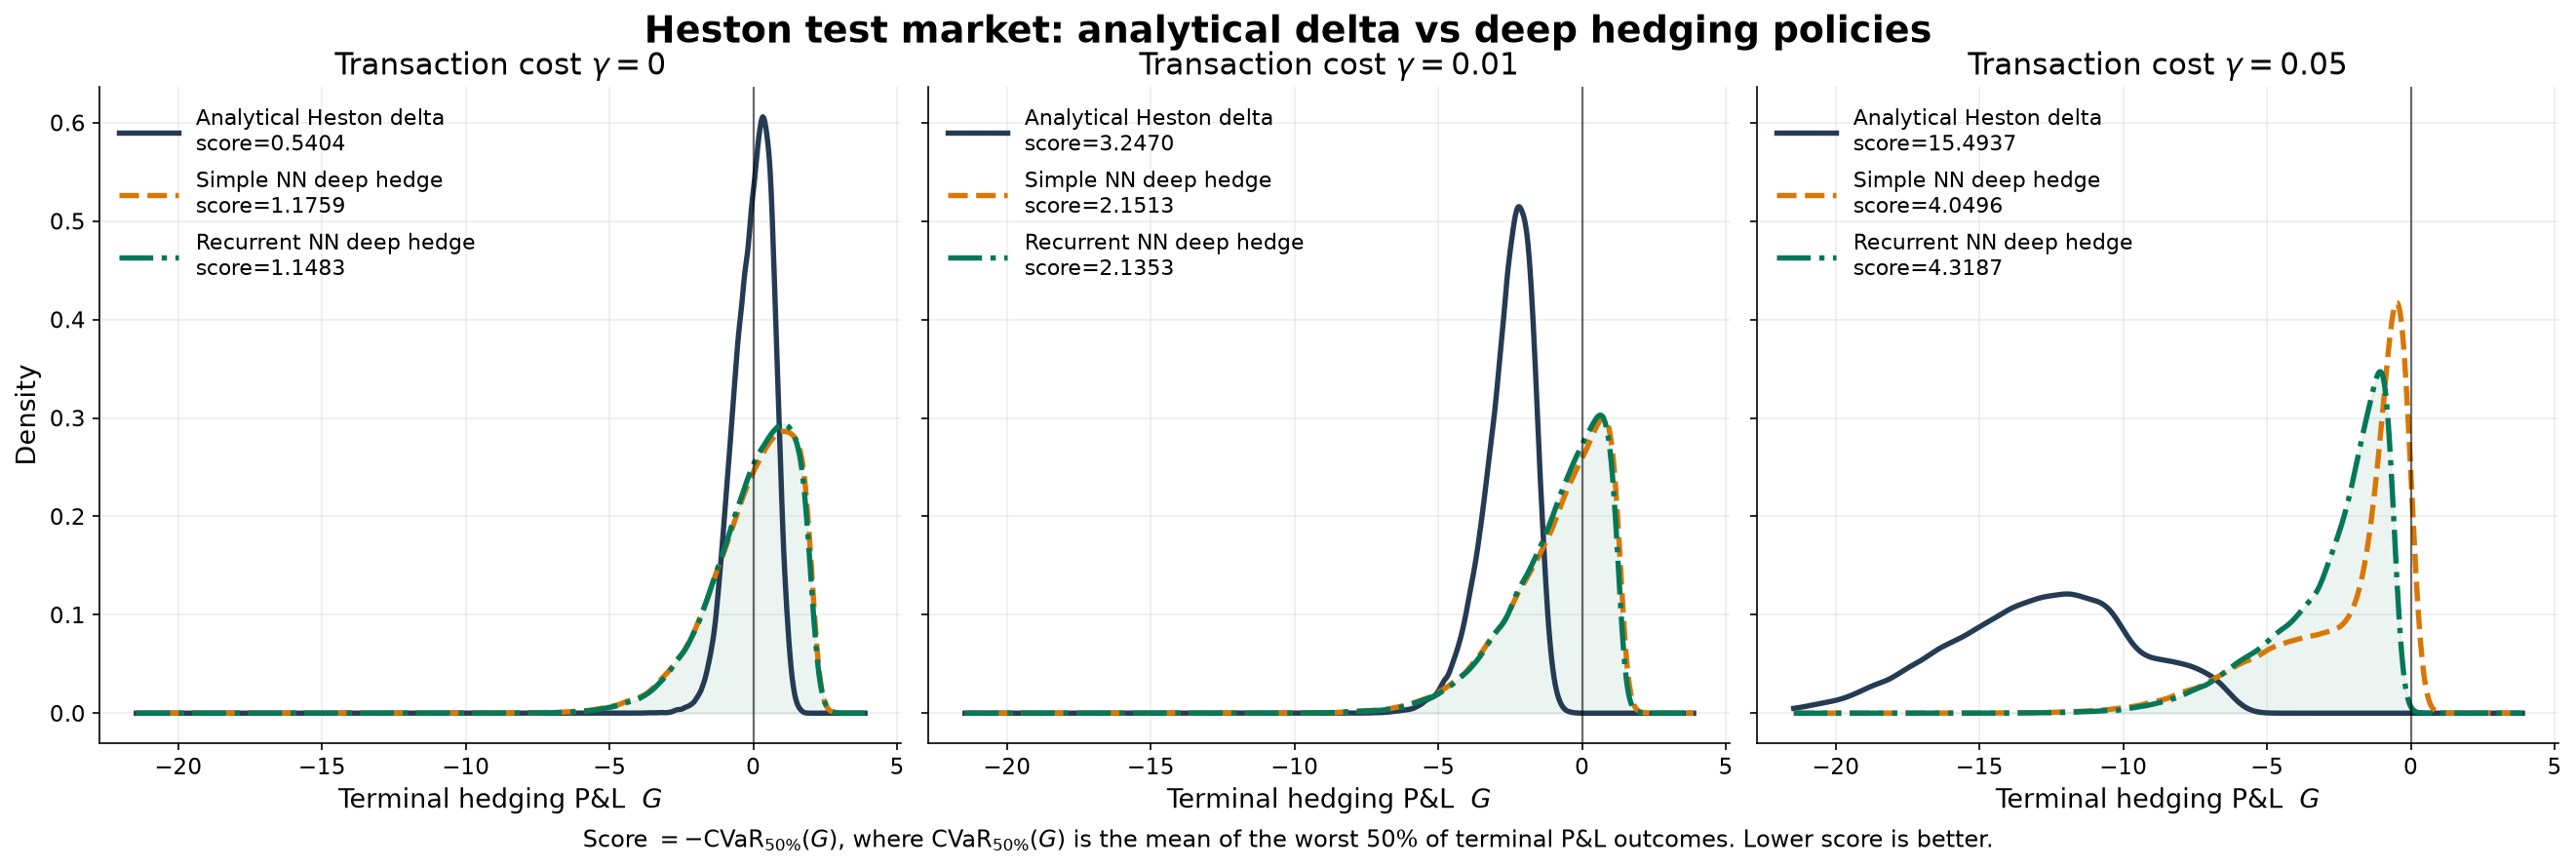

Saved figure:
  /Users/antareepgogoi/Quant Finance/antareep_gbm_heston_patch 3/outputs/figures/heston_gamma_sweep_density.png
  /Users/antareepgogoi/Quant Finance/antareep_gbm_heston_patch 3/outputs/figures/heston_gamma_sweep_density.pdf


In [25]:
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.8,
})

colors = {
    "Analytical Heston delta": "#243B53",
    "Simple NN deep hedge": "#D97706",
    "Recurrent NN deep hedge": "#047857",
}

linestyles = {
    "Analytical Heston delta": "-",
    "Simple NN deep hedge": "--",
    "Recurrent NN deep hedge": "-.",
}

# Robust common x-limits across all panels, avoiding extreme KDE stretching.
pooled = np.concatenate([
    np.asarray(pnl, dtype=float)
    for gamma_results in all_results.values()
    for pnl in gamma_results.values()
])
x_low, x_high = np.quantile(pooled, [0.0025, 0.9975])
pad = 0.08 * (x_high - x_low)
x_grid = np.linspace(x_low - pad, x_high + pad, 700)

fig, axes = plt.subplots(
    1,
    len(COST_GAMMAS),
    figsize=(17.5, 5.3),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

if len(COST_GAMMAS) == 1:
    axes = [axes]

for ax, gamma in zip(axes, COST_GAMMAS):
    strategy_dict = all_results[gamma]

    for strategy, pnl in strategy_dict.items():
        pnl = np.asarray(pnl, dtype=float)

        kde = gaussian_kde(pnl)
        density = kde(x_grid)

        score = score_neg_cvar50(pnl)
        label = f"{strategy}\nscore={score:.4f}"

        ax.plot(
            x_grid,
            density,
            color=colors[strategy],
            linestyle=linestyles[strategy],
            linewidth=2.6,
            label=label,
        )

        # Light fill only for the recurrent model, to highlight the proposed method.
        if strategy == "Recurrent NN deep hedge":
            ax.fill_between(
                x_grid,
                0,
                density,
                color=colors[strategy],
                alpha=0.08,
            )

    ax.axvline(0.0, color="black", linewidth=1.1, alpha=0.55)
    ax.set_title(rf"Transaction cost $\gamma={gamma:g}$")
    ax.set_xlabel("Terminal hedging P&L  $G$")
    ax.legend(frameon=False, loc="upper left", handlelength=2.8)

axes[0].set_ylabel("Density")

fig.suptitle(
    "Heston test market: analytical delta vs deep hedging policies",
    fontsize=18,
    fontweight="bold",
    y=1.04,
)

fig.text(
    0.5,
    -0.035,
    r"Score $= -\mathrm{CVaR}_{50\%}(G)$, where $\mathrm{CVaR}_{50\%}(G)$ is the mean of the worst 50% of terminal P&L outcomes. Lower score is better.",
    ha="center",
    fontsize=11.5,
)

plt.savefig(FIG_PNG, bbox_inches="tight", facecolor="white")
plt.savefig(FIG_PDF, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure:\n  {FIG_PNG}\n  {FIG_PDF}")

Using cached true-Heston result for cost_gamma=0.0
Using cached true-Heston result for cost_gamma=0.001
Using cached true-Heston result for cost_gamma=0.005


,cost_gamma,strategy,Score = -CVaR50%(G),Mean P&L,Std P&L,Median P&L
0,0.000,Analytical Heston $\Delta$,0.54690,-0.00923,0.66938,0.06615
2,0.000,Recurrent NN deep hedge,0.54898,-0.00993,0.70477,0.00643
1,0.000,Simple NN deep hedge,0.60407,-0.01064,0.75328,-0.03204
5,0.001,Recurrent NN deep hedge,0.77881,-0.23263,0.71633,-0.21221
3,0.001,Analytical Heston $\Delta$,0.79453,-0.26283,0.66503,-0.19242
4,0.001,Simple NN deep hedge,0.85882,-0.24941,0.77367,-0.25715
8,0.005,Recurrent NN deep hedge,1.47559,-0.76221,0.90945,-0.69693
7,0.005,Simple NN deep hedge,1.64652,-0.77204,1.10602,-0.67823
6,0.005,Analytical Heston $\Delta$,1.84186,-1.29312,0.70710,-1.20994


cost_gamma,0.000,0.001,0.005
strategy,,,
Analytical Heston $\Delta$,0.54690,0.79453,1.84186
Recurrent NN deep hedge,0.54898,0.77881,1.47559
Simple NN deep hedge,0.60407,0.85882,1.64652


KeyError: 'Analytical Heston Delta'

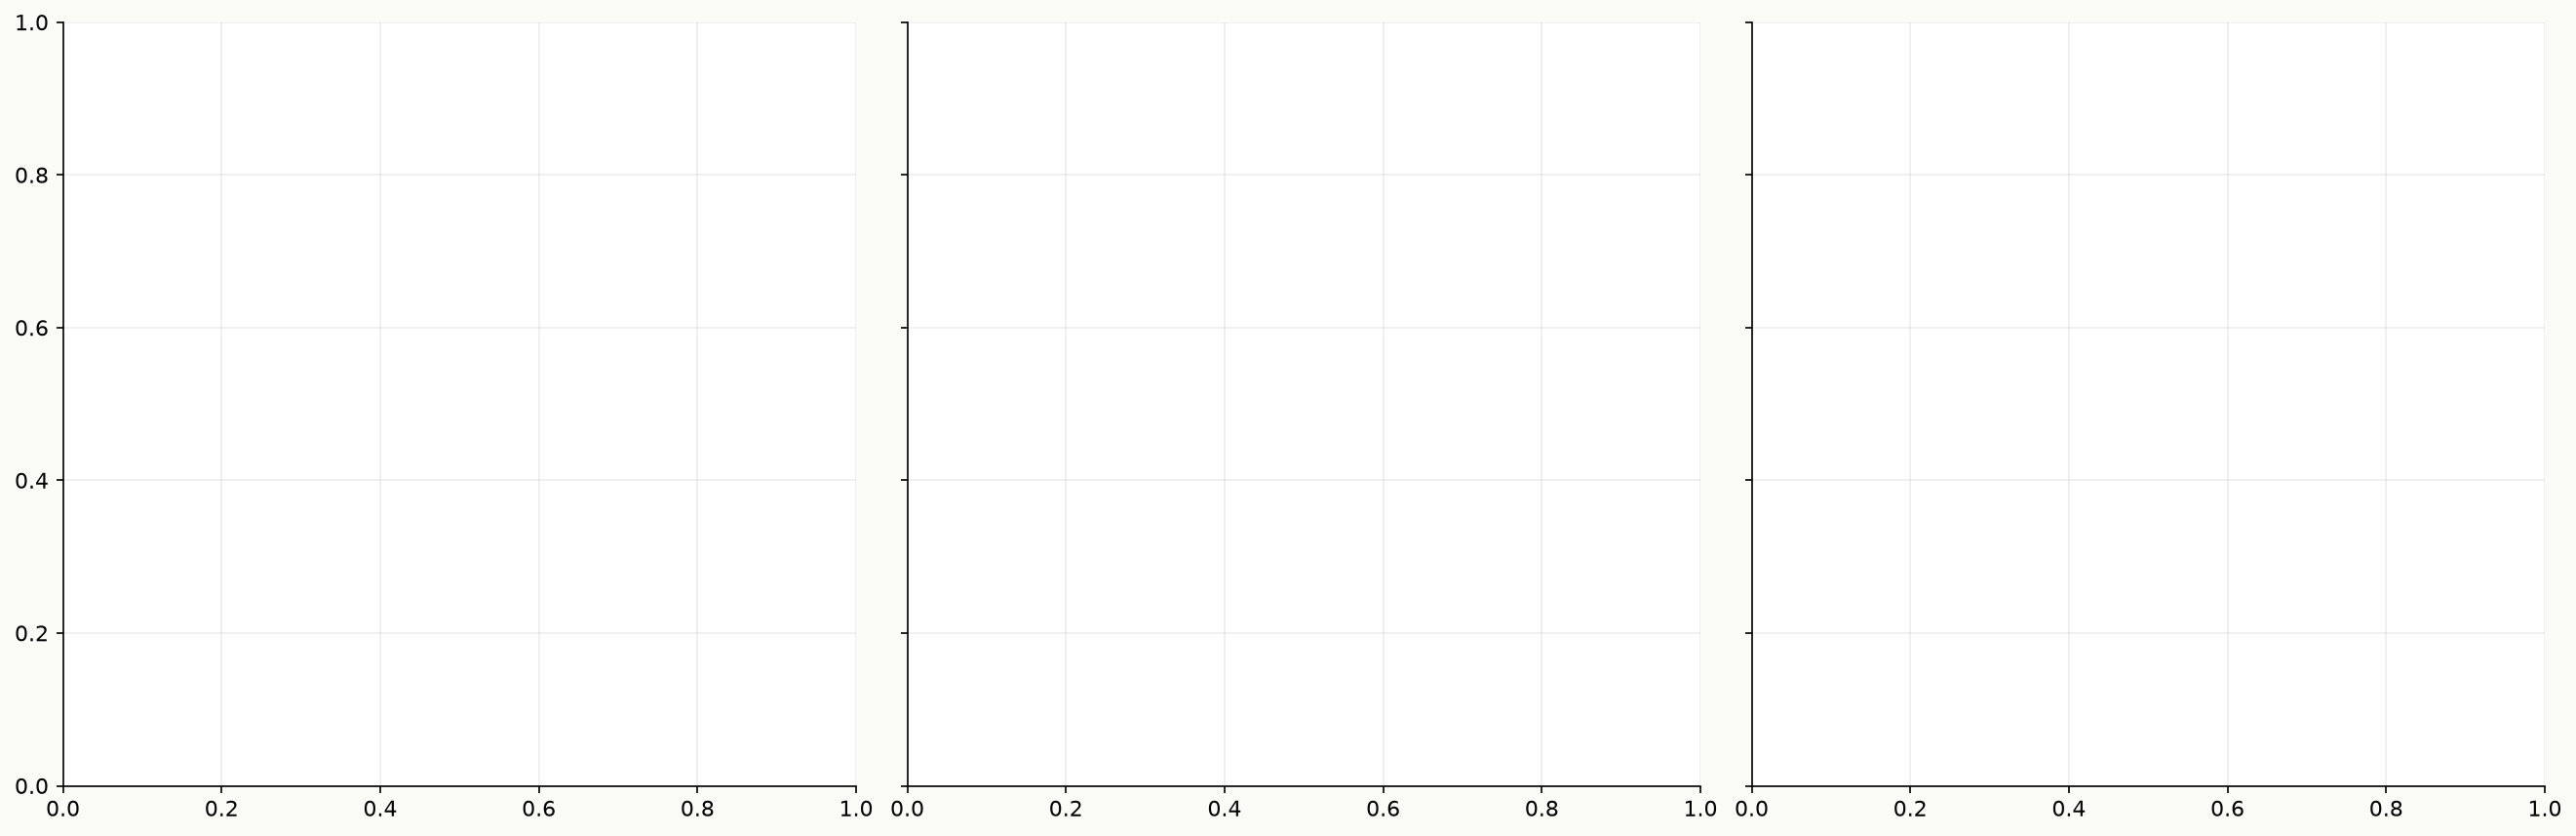

In [ ]:
# ============================================================
# Heston performance sweep: analytical Heston delta vs Deep Hedging NNs
# Score = -CVaR_50%(G), where G is terminal P&L / terminal gain.
# Lower score is better.
#
# This version fixes:
#   1. invalid escape warnings from "\Delta"
#   2. stale cached Heston runs missing the true Heston delta baseline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import gaussian_kde
    SCIPY_KDE_AVAILABLE = True
except Exception:
    SCIPY_KDE_AVAILABLE = False


# ----------------------------
# User controls
# ----------------------------
COST_GAMMAS = [0.0, 0.001, 0.005]

if "RUN_FULL_EXPERIMENT" not in globals():
    RUN_FULL_EXPERIMENT = False

SLIDE_EVAL_PATHS = 100_000 if RUN_FULL_EXPERIMENT else 20_000
SLIDE_EPOCHS = 250 if RUN_FULL_EXPERIMENT else max(BASE.epochs, 50)

SAVE_STEM = OUTPUT_DIR / "figures" / "heston_gamma_sweep_density_pnl"


# ----------------------------
# Score function
# ----------------------------
def to_numpy(x):
    """Convert torch tensor or array-like to a clean NumPy array."""
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]


def cvar_lower_tail(G, alpha=0.50):
    """
    Lower-tail CVaR_alpha(G): average of the worst alpha fraction of terminal gains.

    For alpha = 0.50, this is the average P&L among paths below the median.
    """
    G = to_numpy(G)
    q = np.quantile(G, alpha)
    tail = G[G <= q]
    return float(np.mean(tail))


def project_score(G, alpha=0.50):
    """
    Project score:
        Score = -CVaR_50%(G)

    Lower score means better.
    """
    return -cvar_lower_tail(G, alpha=alpha)


required_raw_names = [
    "Heston delta",
    "Heston-state Simple NN",
    "Heston-state Recurrent NN",
]

strategy_map = {
    "Heston delta": r"Analytical Heston $\Delta$",
    "Heston-state Simple NN": r"Simple NN $\Delta$ hedge",
    "Heston-state Recurrent NN": r"Recurrent NN $\Delta$ hedge",
}

def result_has_required_strategies(out):
    """Check whether a cached Heston result contains the true Heston baseline."""
    if not isinstance(out, dict):
        return False
    if "results" not in out:
        return False
    return all(name in out["results"] for name in required_raw_names)


# ----------------------------
# Run or reuse Heston scenarios
# ----------------------------
if "heston_gamma_sweep" not in globals():
    heston_gamma_sweep = {}

existing_names = {
    0.0: "heston_no_cost",
    0.005: "heston_cost",
}

for gamma in COST_GAMMAS:

    # First try the explicit sweep cache.
    if gamma in heston_gamma_sweep and result_has_required_strategies(heston_gamma_sweep[gamma]):
        print(f"Using cached true-Heston result for cost_gamma={gamma}")
        continue

    # Then try old notebook variables, but only if they already contain the true Heston delta.
    existing_var = existing_names.get(gamma)
    if existing_var is not None and existing_var in globals():
        candidate = globals()[existing_var]
        if result_has_required_strategies(candidate):
            print(f"Reusing existing true-Heston variable `{existing_var}` for cost_gamma={gamma}")
            heston_gamma_sweep[gamma] = candidate
            continue
        else:
            print(
                f"`{existing_var}` exists but is stale/missing true Heston delta. "
                f"Re-running cost_gamma={gamma}."
            )

    # Otherwise rerun.
    print(f"\nRunning Heston scenario for cost_gamma={gamma}")

    cfg = BASE.with_updates(
        cost_gamma=gamma,
        eval_paths=SLIDE_EVAL_PATHS,
        epochs=SLIDE_EPOCHS,
    )

    S_test, v_test = simulate_heston(cfg.eval_paths, cfg)

    out = run_heston_scenario(
        cfg,
        (S_test, v_test),
        scenario_name=f"Heston gamma {gamma:g}",
    )

    # Helpful diagnostic if the function is not returning what we expect.
    if not result_has_required_strategies(out):
        print("\nAvailable result keys were:")
        print(list(out.get("results", {}).keys()))
        raise KeyError(
            "The Heston scenario did not return the expected strategy keys. "
            "Expected keys are: 'Heston delta', 'Heston-state Simple NN', "
            "and 'Heston-state Recurrent NN'."
        )

    heston_gamma_sweep[gamma] = out


# ----------------------------
# Build table data
# ----------------------------
plot_data = {}
score_rows = []

for gamma in COST_GAMMAS:
    out = heston_gamma_sweep[gamma]
    plot_data[gamma] = {}

    for raw_name, pretty_name in strategy_map.items():
        G = to_numpy(out["results"][raw_name][0])
        score = project_score(G, alpha=0.50)

        plot_data[gamma][pretty_name] = {
            "G": G,
            "score": score,
        }

        score_rows.append({
            "cost_gamma": gamma,
            "strategy": pretty_name,
            "Score = -CVaR50%(G)": score,
            "Mean P&L": np.mean(G),
            "Std P&L": np.std(G, ddof=1),
            "Median P&L": np.median(G),
        })

score_df = pd.DataFrame(score_rows)

display(
    score_df
    .sort_values(["cost_gamma", "Score = -CVaR50%(G)"])
    .round(5)
)

score_pivot = (
    score_df
    .pivot(index="strategy", columns="cost_gamma", values="Score = -CVaR50%(G)")
)

display(score_pivot.round(5))


# ----------------------------
# Density helper
# ----------------------------
def density_curve(x, grid):
    """
    Smooth density curve. Uses Gaussian KDE when SciPy is available;
    otherwise falls back to a smoothed histogram.
    """
    x = to_numpy(x)

    if SCIPY_KDE_AVAILABLE and len(x) > 5 and np.std(x) > 1e-12:
        kde = gaussian_kde(x)
        return kde(grid)

    hist, edges = np.histogram(x, bins=90, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return np.interp(grid, centers, hist, left=0.0, right=0.0)


# Common x-axis, trimmed to avoid extreme outliers ruining the slide.
all_G = np.concatenate([
    plot_data[gamma][strategy]["G"]
    for gamma in COST_GAMMAS
    for strategy in strategy_map.values()
])

x_lo, x_hi = np.quantile(all_G, [0.005, 0.995])
pad = 0.08 * (x_hi - x_lo)
x_grid = np.linspace(x_lo - pad, x_hi + pad, 700)


# ----------------------------
# Aesthetic plotting
# ----------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

colors = {
    r"Analytical Heston $\Delta$": "#1F4E79",
    r"Simple NN $\Delta$ hedge": "#D55E00",
    r"Recurrent NN $\Delta$ hedge": "#009E73",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(17.5, 5.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

fig.patch.set_facecolor("#FAFAF7")

for ax, gamma in zip(axes, COST_GAMMAS):
    ax.set_facecolor("#FFFFFF")

    for strategy, color in colors.items():
        G = plot_data[gamma][strategy]["G"]
        score = plot_data[gamma][strategy]["score"]
        y = density_curve(G, x_grid)

        ax.plot(
            x_grid,
            y,
            lw=2.7,
            color=color,
            label=f"{strategy}\nScore={score:.4f}",
        )

        ax.fill_between(
            x_grid,
            0,
            y,
            color=color,
            alpha=0.13,
            linewidth=0,
        )

    ax.axvline(
        0.0,
        color="#222222",
        lw=1.2,
        alpha=0.65,
        linestyle="--",
    )

    ax.grid(
        True,
        which="major",
        color="#D9D9D9",
        alpha=0.45,
        linewidth=0.8,
    )

    ax.set_title(rf"$c_s = {gamma:g}$")
    ax.set_xlabel(r"P&L")
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="#CCCCCC",
        framealpha=0.93,
        loc="upper left",
    )

axes[0].set_ylabel("Density")

fig.suptitle(
    "Heston Market: Analytical Delta Hedging vs Deep Delta Hedgers",
    fontsize=18,
    fontweight="bold",
    y=1.05,
)

fig.text(
    0.5,
    -0.035,
    r"Score $= -\mathrm{CVaR}_{50\%}(G)$, so lower is better. "
    r"All methods use the same Heston test paths for each transaction-cost level.",
    ha="center",
    fontsize=11,
    color="#444444",
)

SAVE_STEM.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(f"{SAVE_STEM}.png", bbox_inches="tight")
fig.savefig(f"{SAVE_STEM}.pdf", bbox_inches="tight")

plt.show()

print(f"Saved figure to:\n  {SAVE_STEM}.png\n  {SAVE_STEM}.pdf")

In [30]:
# Rescue the run that just finished before the KeyError
if "out" in globals() and isinstance(out, dict) and "Heston delta" in out.get("results", {}):
    heston_gamma_sweep[0.0] = out
    print("Saved the just-completed cost_gamma=0.0 run into heston_gamma_sweep[0.0].")

Saved the just-completed cost_gamma=0.0 run into heston_gamma_sweep[0.0].
